In [ ]:
# !pip install torch==2.3.1 --extra-index-url https://download.pytorch.org/whl/cu121
# !pip install -U "transformers==4.45.2" "trl==0.9.6" "accelerate>=0.29.0" "peft>=0.12.0" unsloth
# !pip install -U "huggingface_hub==0.23.4"
# !pip install unsloth
# !pip install "transformers==4.56.1" "tokenizers==0.20.3" "trl==0.9.6" "peft==0.17.1" "accelerate==1.10.1" "huggingface_hub==0.34.4" "bitsandbytes==0.47.0"

In [1]:
%%capture
import os
os.environ["UNSLOTH_VLLM_STANDBY"] = "1" # [NEW] Extra 30% context lengths!
!pip install --upgrade -qqq uv
try: import numpy; get_numpy = f"numpy=={numpy.__version__}"
except: get_numpy = "numpy"
try: import subprocess; is_t4 = "Tesla T4" in str(subprocess.check_output(["nvidia-smi"]))
except: is_t4 = False
get_vllm, get_triton = ("vllm==0.10.1", "triton==3.2.0") if is_t4 else ("vllm", "triton")
!uv pip install -qqq --upgrade     unsloth {get_vllm} {get_numpy} torchvision bitsandbytes xformers
!uv pip install -qqq {get_triton}
!uv pip install "huggingface_hub>=0.34.0" "datasets>=3.4.1,<4.0.
!uv pip install transformers==4.55.4
!uv pip install "trl==0.9.6"

In [ ]:
from unsloth import FastLanguageModel
from peft import LoraConfig
from trl import DataCollatorForCompletionOnlyLM
# I changed it so unsloth is imported first. might breaks tuff

In [2]:

class InputMaskingDataCollator(DataCollatorForCompletionOnlyLM):
    def __init__(self, mask_first_n_examples=0, **kwargs):
        super().__init__(**kwargs)
        self.mask_first_n_examples = mask_first_n_examples

    def torch_call(self, examples):
        batch = super().torch_call(examples)  # call super, masking all inputs
        for i in range(len(batch['labels'])):
            for _ in range(self.mask_first_n_examples):
                # mask first still unmasked output block
                beg_pos = ((batch['labels'][i] != -100).nonzero().min()).item()
                mid_pos = ((batch['labels'][i][beg_pos:] == -100).nonzero().min()).item() + beg_pos
                end_pos = ((batch['labels'][i] != -100).nonzero().max()).item() + 1
                if mid_pos < end_pos:
                    batch['labels'][i][beg_pos:mid_pos] = -100
        return batch

2025-09-10 12:10:55.305423: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757506255.671318      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757506255.777898      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [4]:
def get_or_map_special_tokens(data, mapping=None):
    tokens = set()
    if isinstance(data, dict):
        special = data.get('special_tokens')
        if special is not None:  # find and/or update special token mappings
            for v in special.values():
                tokens.update(v['ids'])
                if mapping is not None:
                    v['ids'] = [mapping.get(i) for i in v['ids'] if i in mapping]
        for v in data.values():  # recursively process dict values
            tokens.update(get_or_map_special_tokens(v, mapping))
    if isinstance(data, list):
        for v in data:  # recursively process lists
            tokens.update(get_or_map_special_tokens(v, mapping))
    return tokens
    
def remove_tokenizer_normalizer(tokenizer):
    assert tokenizer.is_fast
    tokenizer_json = json.loads(tokenizer._tokenizer.to_str())
    if tokenizer_json.get('normalizer') is not None:
        tokenizer_json['normalizer'] = None
        tokenizer._tokenizer = Tokenizer.from_str(json.dumps(tokenizer_json))


def shrink_tokenizer_vocab(tokenizer, keep_indices, keep_special=True, remove_unk=False):
    assert tokenizer.is_fast
    tok_json = json.loads(tokenizer._tokenizer.to_str())
    assert tok_json['model']['type'] == "BPE"

    if keep_special:  # get special tokens to keep
        keep_indices.update(tokenizer.all_special_ids)
        keep_indices.update(get_or_map_special_tokens(tok_json.get('post_processor')))

    if remove_unk:  # remove unknown token
        keep_indices -= {tokenizer.unk_token_id}

    # build mapping from old to new id
    mapping = {old: new for new, old in enumerate(sorted(keep_indices))}

    # update tokenizer info
    tok_json['model']['vocab'] = {k: mapping[v] for k, v in tok_json['model']['vocab'].items() if v in mapping}
    tok_json['model']['merges'] = []
    tok_json['added_tokens'] = [{**t, 'id': mapping[t['id']]} for t in tok_json['added_tokens'] if t['id'] in mapping]
    tok_json['added_tokens'] = sorted(tok_json['added_tokens'], key=lambda t: t['id'])
    get_or_map_special_tokens(tok_json.get('post_processor'), mapping)

    tokenizer._tokenizer = Tokenizer.from_str(json.dumps(tok_json))  # reload json, modifying tokenizer in-place

    if remove_unk:
        tokenizer.unk_token = None

    return mapping  # token mapping to be used later


def shrink_model_embeddings(model, mapping):
    with torch.no_grad():
        # copy embeddings to keep
        row_select = torch.tensor([x[0] for x in sorted(mapping.items(), key=lambda x: x[1])])
        row_select = row_select.to(model.get_input_embeddings().weight.data.device)
        new_embed_t = torch.index_select(model.get_input_embeddings().weight.data, 0, row_select)
        row_select = row_select.to(model.get_output_embeddings().weight.data.device)
        new_lm_head = torch.index_select(model.get_output_embeddings().weight.data, 0, row_select)

        # resize model embeddings
        model.resize_token_embeddings(len(row_select))

        # set to copied values
        model.get_input_embeddings().weight.data[:] = new_embed_t
        model.get_output_embeddings().weight.data[:] = new_lm_head

        # map model tokens to new id
        for config in [model.config, model.generation_config]:
            for k, v in list(config.to_dict().items()):
                if k.endswith('token_id'):
                    setattr(config, k, [mapping.get(t) for t in v] if isinstance(v, list) else mapping.get(v))


def keep_single_char_tokens(model, tokenizer, keep=None, keep_norm=False, keep_model_tok=True, **kwargs):
    if not keep_norm:
        remove_tokenizer_normalizer(tokenizer)  # required for some models
    if keep is None:  # keep all single_length tokens
        keep_indices = set(v for k, v in tokenizer.vocab.items() if len(k) == 1)
    else:  # keep tokens that were passed
        keep_indices = set(tokenizer.vocab[t] for t in keep)
    if keep_model_tok:  # keep tokens used by model
        for config in [model.config, model.generation_config]:
            for k, v in config.to_dict().items():
                if k.endswith('token_id'):
                    keep_indices.update(v if isinstance(v, list) else [v])
    keep_indices -= {None}
    mapping = shrink_tokenizer_vocab(tokenizer, keep_indices, **kwargs)
    shrink_model_embeddings(model, mapping)
    return mapping

In [5]:




def load_unsloth_model(
    base_model_id: str = "meta-llama/Llama-3.1-8B",
    use_qlora: bool = True,        # 4-bit QLoRA
    r: int = 16, lora_alpha: int = 32, lora_dropout: float = 0.00,
    target_modules=("q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"),
):
    model, tokenizer = FastLanguageModel.from_pretrained(
        base_model_id,
        load_in_4bit=use_qlora,
        device_map="auto"
    )

    model = FastLanguageModel.get_peft_model(
        model,
        r=r,
        lora_alpha=lora_alpha,
        lora_dropout=lora_dropout,
        target_modules=list(target_modules),
        bias="none",
        use_rslora=False,              # flip if you want RS-LoRA
        use_dora=False,                # flip if you want DoRA
    )

    FastLanguageModel.for_training(model)

    return model, tokenizer

/tmp/ipykernel_36/2594340489.py:1: UserWarning: WARNING: Unsloth should be imported before trl, transformers, peft to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from unsloth import FastLanguageModel


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
INFO 09-10 12:11:36 [__init__.py:241] Automatically detected platform cuda.
ERROR 09-10 12:11:37 [fa_utils.py:57] Cannot use FA version 2 is not supported due to FA2 is only supported on devices with compute capability >= 8
🦥 Unsloth Zoo will now patch everything to make training faster!


In [6]:
model, tokenizer = load_unsloth_model()

==((====))==  Unsloth 2025.9.3: Fast Llama patching. Transformers: 4.55.4. vLLM: 0.10.1.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.7.1+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.3.1
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.31. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.96G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/235 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/459 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

Unsloth 2025.9.3 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


In [11]:
import json
from tokenizers import Tokenizer
import torch
keep_tok = list('ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz0123456789!?.:,;*+/-=')+tokenizer.tokenize('\n')
keep_single_char_tokens(model, tokenizer, keep=keep_tok, remove_unk=True)

{0: 0,
 1: 1,
 2: 2,
 3: 3,
 4: 4,
 5: 5,
 6: 6,
 7: 7,
 8: 8,
 9: 9,
 10: 10,
 11: 11,
 12: 12,
 13: 13,
 14: 14,
 15: 15,
 16: 16,
 17: 17,
 18: 18,
 19: 19,
 20: 20,
 21: 21,
 22: 22,
 23: 23,
 24: 24,
 25: 25,
 26: 26,
 27: 27,
 28: 28,
 29: 29,
 30: 30,
 31: 31,
 32: 32,
 33: 33,
 34: 34,
 35: 35,
 36: 36,
 37: 37,
 38: 38,
 39: 39,
 40: 40,
 41: 41,
 42: 42,
 43: 43,
 44: 44,
 45: 45,
 46: 46,
 47: 47,
 48: 48,
 49: 49,
 50: 50,
 51: 51,
 52: 52,
 53: 53,
 54: 54,
 55: 55,
 56: 56,
 57: 57,
 58: 58,
 59: 59,
 60: 60,
 61: 61,
 62: 62,
 63: 63,
 64: 64,
 65: 65,
 66: 66,
 67: 67,
 68: 68,
 69: 69,
 70: 70,
 71: 71,
 72: 72,
 73: 73,
 74: 74,
 75: 75,
 76: 76,
 128000: 77,
 128001: 78,
 128004: 79}

In [12]:
import json, os

BASE = "/kaggle/input/arc-2024"

with open(os.path.join(BASE, "arc-agi_training_challenges.json")) as f:
    train_chal = json.load(f)

with open(os.path.join(BASE, "arc-agi_training_solutions.json")) as f:
    train_sol = json.load(f)

In [13]:
  
fmt_opts = dict(
        preprompt='ABCDEFGHJKLMNPQRSTUVWXYZabcdefghjklmnpqrstuvwxyz',
        query_beg='I',
        reply_beg='\n+/-=O',
        reply_end='\n' + str(tokenizer.eos_token),
        lines_sep='\n',
        max_tokens=8192,
    )

def fmt_test_inp(fmt_opts: dict, task_id:str):
    example = train_chal[task_id]['test'][0]['input'].copy()
    ex_str = fmt_opts["query_beg"]
    ex_str += "\n".join(''.join(map(str, row)) for row in example)
    ex_str += fmt_opts["reply_beg"]

    return ex_str

def fmt_train(fmt_opts: dict, task_id: str):
    examples = train_chal[task_id].copy()
    ex_str = fmt_opts["preprompt"]
    for i, example in enumerate(examples["train"]):
        ex_str += fmt_opts["query_beg"]
        ex_str += "\n".join(''.join(map(str, row)) for row in example['input'])
        ex_str += fmt_opts["reply_beg"]
        ex_str += "\n".join(''.join(map(str, row)) for row in example['output'])
        ex_str += fmt_opts['reply_end']

    return ex_str

def fmt_test_sol(fmt_opts:dict, task_id:str):
    solution = train_sol[task_id][0].copy()
    solution_str = "\n".join(''.join(map(str,row)) for row in solution)
    solution_str += fmt_opts["reply_end"]
 
    return solution_str

In [14]:
def fmt_task(fmt_opts:dict, task_id: str):
    ret = dict(key=task_id)
    #train is all the training examples that are in the data
    ret['train'] = fmt_train(fmt_opts, task_id)
    # query is the test input
    ret['query'] = fmt_test_inp(fmt_opts, task_id)
    ret['input'] = ret['train'] + ret['query']
    ret['reply'] = fmt_test_sol(fmt_opts, task_id)

    ret['text'] = ret['train'] + ret['query'] + ret['reply']
    return ret

from datasets import Dataset

samples = []
for task_id in train_chal.keys():
    d = fmt_task(fmt_opts, task_id)      # your function
    samples.append(d)  

sample_batch = [{"text": s["text"]} for s in samples]  # IMPORTANT: only 'text'

train_data = [{"prompt": s["input"], "response": s["reply"]} for s in samples]

In [15]:

with open(os.path.join(BASE, "arc-agi_evaluation_challenges.json")) as f:
    eval_chal = json.load(f)

with open(os.path.join(BASE, "arc-agi_evaluation_solutions.json")) as f:
    eval_sol = json.load(f)

In [16]:
eval_chal['00576224']

{'test': [{'input': [[3, 2], [7, 8]]}],
 'train': [{'input': [[8, 6], [6, 4]],
   'output': [[8, 6, 8, 6, 8, 6],
    [6, 4, 6, 4, 6, 4],
    [6, 8, 6, 8, 6, 8],
    [4, 6, 4, 6, 4, 6],
    [8, 6, 8, 6, 8, 6],
    [6, 4, 6, 4, 6, 4]]},
  {'input': [[7, 9], [4, 3]],
   'output': [[7, 9, 7, 9, 7, 9],
    [4, 3, 4, 3, 4, 3],
    [9, 7, 9, 7, 9, 7],
    [3, 4, 3, 4, 3, 4],
    [7, 9, 7, 9, 7, 9],
    [4, 3, 4, 3, 4, 3]]}]}

In [17]:
def eval_fmt_test_inp(fmt_opts: dict, task_id:str):
    example = eval_chal[task_id]['test'][0]['input'].copy()
    ex_str = fmt_opts["query_beg"]
    ex_str += "\n".join(''.join(map(str, row)) for row in example)
    ex_str += fmt_opts["reply_beg"]

    return ex_str

def eval_fmt_train(fmt_opts: dict, task_id: str):
    examples = eval_chal[task_id].copy()
    ex_str = fmt_opts["preprompt"]
    for i, example in enumerate(examples["train"]):
        ex_str += fmt_opts["query_beg"]
        ex_str += "\n".join(''.join(map(str, row)) for row in example['input'])
        ex_str += fmt_opts["reply_beg"]
        ex_str += "\n".join(''.join(map(str, row)) for row in example['output'])
        ex_str += fmt_opts['reply_end']

    return ex_str

def eval_fmt_test_sol(fmt_opts:dict, task_id:str):
    solution = eval_sol[task_id][0].copy()
    solution_str = "\n".join(''.join(map(str,row)) for row in solution)
    solution_str += fmt_opts["reply_end"]
 
    return solution_str

def eval_fmt_task(fmt_opts:dict, task_id: str):
    ret = dict(key=task_id)
    #train is all the training examples that are in the data
    ret['train'] = eval_fmt_train(fmt_opts, task_id)
    # query is the test input
    ret['query'] = eval_fmt_test_inp(fmt_opts, task_id)
    ret['input'] = ret['train'] + ret['query']
    ret['reply'] = eval_fmt_test_sol(fmt_opts, task_id)

    ret['text'] = ret['train'] + ret['query'] + ret['reply']
    return ret
    
eval_samples = []
for task_id in eval_chal.keys():
    d = eval_fmt_task(fmt_opts, task_id)      # your function
    eval_samples.append(d)  

eval_batch = [{"text": s["text"]} for s in eval_samples]  # IMPORTANT: only 'text'


In [19]:
from unsloth.chat_templates import train_on_responses_only


In [18]:
import os
from unsloth import FastLanguageModel
from unsloth import UnslothTrainer as Trainer, unsloth_train, is_bfloat16_supported
from unsloth import UnslothTrainingArguments as TrainingArguments
from datasets import Dataset

In [ ]:
FastLanguageModel.for_training(model)
tokenizer.padding_side = 'right'
trainer = Trainer(
            model=model,
            tokenizer=tokenizer,
            train_dataset=Dataset.from_list(samples),
            dataset_text_field="text",
            max_seq_length=fmt_opts['max_tokens'],
            packing=False,
            data_collator=InputMaskingDataCollator(
                instruction_template=fmt_opts['query_beg'],
                response_template=fmt_opts['reply_beg'],
                mlm=False,
                tokenizer=tokenizer,
                mask_first_n_examples=1,
            ),
            args=TrainingArguments(
                per_device_train_batch_size=4,
                gradient_accumulation_steps=2,
                warmup_ratio=0.25,
                num_train_epochs=1,
                learning_rate=1e-4,
                embedding_learning_rate=1e-5,
                fp16=not is_bfloat16_supported(),
                bf16=is_bfloat16_supported(),
                logging_steps=10,
                optim="adamw_8bit",
                weight_decay=0.00,
                lr_scheduler_type='cosine',
                seed=42,
                output_dir='tmp_output',
                save_strategy='no',
                report_to='none',
            ),
        )
trainer_stats = unsloth_train(trainer)


/kaggle/working/unsloth_compiled_cache/UnslothSFTTrainer.py:581: UserWarning: You passed a `max_seq_length` argument to the SFTTrainer, the value you passed will override the one in the `SFTConfig`.
  warnings.warn(
/kaggle/working/unsloth_compiled_cache/UnslothSFTTrainer.py:619: UserWarning: You passed a `dataset_text_field` argument to the SFTTrainer, the value you passed will override the one in the `SFTConfig`.
  warnings.warn(


Map (num_proc=8):   0%|          | 0/400 [00:00<?, ? examples/s]

/kaggle/working/unsloth_compiled_cache/UnslothSFTTrainer.py:714: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `UnslothTrainer.__init__`. Use `processing_class` instead.
  super().__init__(
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 2
   \\   /|    Num examples = 400 | Num Epochs = 1 | Total steps = 50
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 2 x 1) = 8
 "-____-"     Trainable parameters = 41,943,040 of 7,022,186,496 (0.60% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss


In [37]:
# samples = []
# for task_id in train_chal.keys():
#     d = fmt_task(fmt_opts, task_id)      # your function
#     samples.append(d)  

# sample_batch = [{"text": s["text"]} for s in samples]  # IMPORTANT: only 'text'

# train_data = [{"prompt": s["input"], "response": s["reply"]} for s in samples]
# samples[0]['input']
print(samples[2]['input'])
print("-"*100)
print(eval_samples[2]['input'])

ABCDEFGHJKLMNPQRSTUVWXYZabcdefghjklmnpqrstuvwxyzI010
110
010
011
010
110
+/-=O020
220
020
022
020
220
020
022
020
<|end_of_text|>I010
101
010
101
010
101
+/-=O020
202
020
202
020
202
020
202
020
<|end_of_text|>I010
110
010
010
110
010
+/-=O020
220
020
020
220
020
020
220
020
<|end_of_text|>I111
010
010
111
010
010
+/-=O
----------------------------------------------------------------------------------------------------
ABCDEFGHJKLMNPQRSTUVWXYZabcdefghjklmnpqrstuvwxyzI2222200
2000200
2020200
2000200
2222200
0000000
0000000
+/-=O2222200
2888200
2828200
2888200
2222200
0000000
0000000
<|end_of_text|>I222222200
200000200
200000200
200200200
200000200
200000200
222222200
000000000
000000000
+/-=O222222200
244444200
244444200
244244200
244444200
244444200
222222200
000000000
000000000
<|end_of_text|>I000000222222222
000000200000002
000000200000002
000000200000002
000000200020002
000000200000002
000000200000002
000000200000002
000000222222222
000000000000000
022222000000000
020002000000000
02

In [ ]:
# Put model into inference mode
FastLanguageModel.for_inference(model)

In [77]:

# Example input (make sure to match your formatting templates)
prompt = eval_samples[3]['input']
print(prompt)
print("-" * 50)
# Tokenize and run generation
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
outputs = model.generate(
    **inputs,
    max_new_tokens=200,
    temperature=0.7,
    do_sample=True,
)

# Decode
output_str = tokenizer.decode(outputs[0], skip_special_tokens=True)
#print(output_str)

ABCDEFGHJKLMNPQRSTUVWXYZabcdefghjklmnpqrstuvwxyzI0000000000
0000000000
0000000000
0000000000
0000000000
0000000000
0000000004
1100000004
1102203304
1102203304
+/-=O1100000000
1100000000
1220000000
0233000000
0034000000
0004000000
0004000000
0004000000
0000000000
0000000000
<|end_of_text|>I0000000000
0000000000
0000000000
0000000000
0000000000
0000000000
8880000000
8880000000
8880770222
8880770222
+/-=O8880000000
8880000000
8880000000
8877000000
0072220000
0002220000
0000000000
0000000000
0000000000
0000000000
<|end_of_text|>I0000000000
0000000000
0000000000
0000000000
0000000000
0000020000
0000020000
0000020333
4444020333
4444020333
+/-=O4444000000
4442000000
0002000000
0002000000
0002000000
0003330000
0003330000
0003330000
0000000000
0000000000
<|end_of_text|>I0000000000
0000000000
0000000000
0000000000
0000000000
0000000000
7000000000
7088060000
7088060330
7088060330
+/-=O
--------------------------------------------------


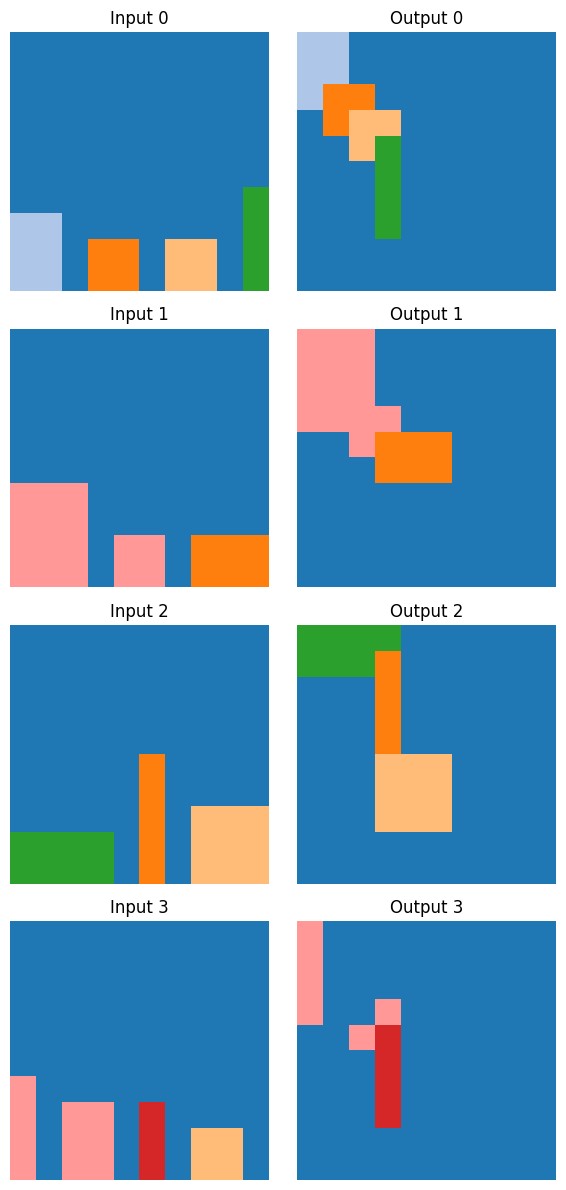

In [78]:
#len("ABCDEFGHJKLMNPQRSTUVWXYZabcdefghjklmnpqrstuvwxyz")
cutoff_string = output_str[48:]

# Split into segments, each starting with 'I'
segments = [seg for seg in cutoff_string.split("I") if seg.strip()]

result = {}
for idx, seg in enumerate(segments):
    # Add back 'I' for parsing
    seg = "I" + seg.strip()
    
    # Split input and output parts
    input_part, output_part = seg.split("+/-=O")

    # Input parsing
    input_clean = input_part.lstrip("I").splitlines()
    input_arr = [[int(ch) for ch in line] for line in input_clean if line]

    # Output parsing
    output_clean = output_part.strip().splitlines()
    output_arr = [[int(ch) for ch in line] for line in output_clean if line]

    # Store with indexed keys
    result[f"input{idx}"] = input_arr
    result[f"output{idx}"] = output_arr


from matplotlib.colors import ListedColormap, BoundaryNorm

# Collect all unique values across inputs/outputs
unique_vals = sorted(set(v for k in result for row in result[k] for v in row))

# Pick a color palette (tab20 has 20 distinct colors)
cmap = ListedColormap(plt.cm.tab20.colors[:len(unique_vals)])
norm = BoundaryNorm(boundaries=np.arange(len(unique_vals)+1)-0.5,
                    ncolors=len(unique_vals))

# Number of input-output pairs
n = len([k for k in result if k.startswith("input")])

fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(6, 3*n))

for i in range(n):
    ax_in = axes[i, 0] if n > 1 else axes[0]
    ax_out = axes[i, 1] if n > 1 else axes[1]

    arr_in = np.array(result[f"input{i}"])
    arr_out = np.array(result[f"output{i}"])

    im_in = ax_in.imshow(arr_in, cmap=cmap, norm=norm)
    ax_in.set_title(f"Input {i}")
    ax_in.axis("off")

    im_out = ax_out.imshow(arr_out, cmap=cmap, norm=norm)
    ax_out.set_title(f"Output {i}")
    ax_out.axis("off")

plt.tight_layout()
plt.show()
    

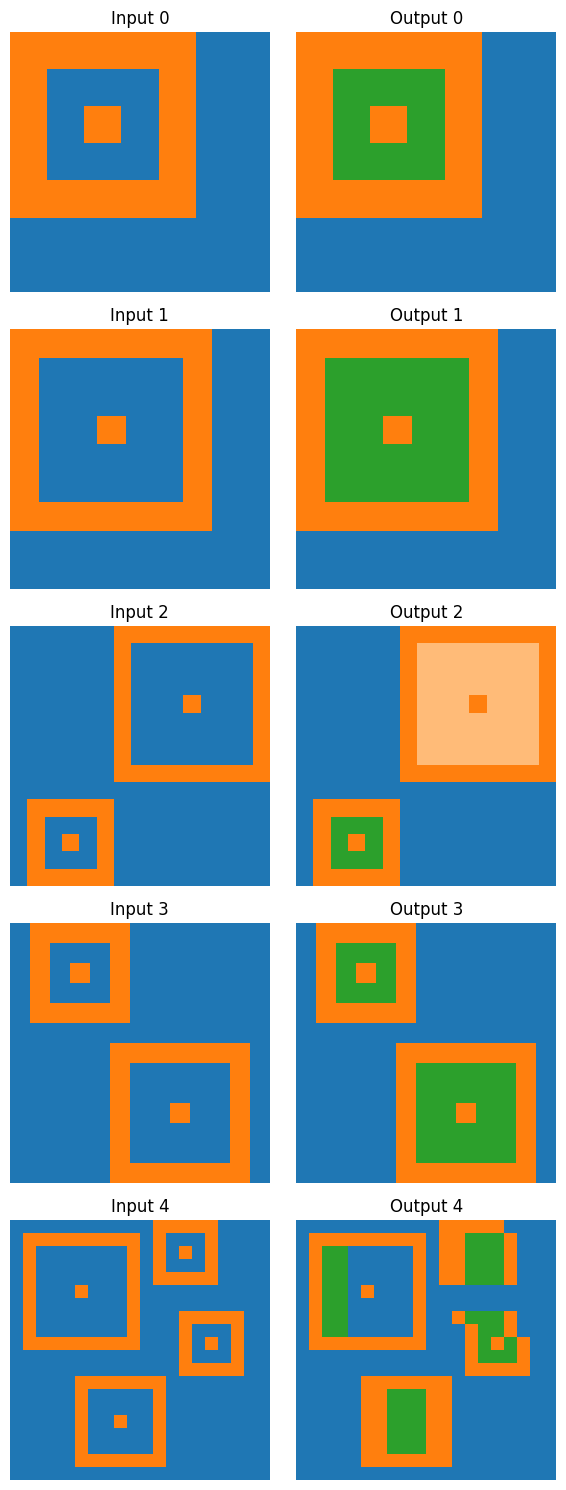

Parsed 1 input/output pairs.
First input grid:
 [[ 4  3 -1 -1 -1 -1]
 [ 4  3  4  3  4  3]
 [ 9  7  9  7  9  7]
 [ 3  4  3  4  3  4]
 [ 7  9  7  9  7  9]
 [ 4  3  4  3  4  3]
 [ 7  8 -1 -1 -1 -1]
 [ 7  8  7  8  7  8]
 [ 3  2  8  3  2  8]
 [ 7  8  7  8  7  8]
 [ 3  2  8  3  2  8]
 [ 7  8  7  8  7  8]]
First output grid shape: (0, 0)


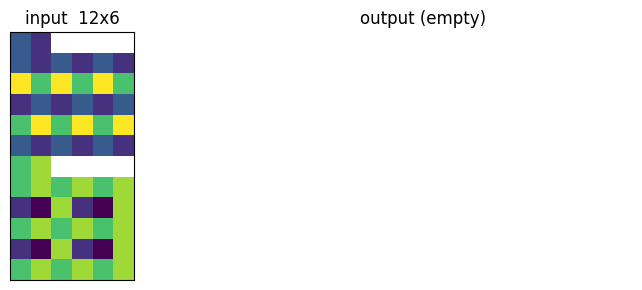

In [55]:
import re
from typing import List, Tuple, Dict
import numpy as np
import matplotlib.pyplot as plt

def _lines_to_grid(lines: List[str]) -> np.ndarray:
    """Convert a list of digit-only strings into a 2D numpy array of ints."""
    grid = []
    for ln in lines:
        ln = ln.strip()
        if not ln or not ln.isdigit():
            continue
        grid.append([int(ch) for ch in ln])
    if not grid:
        return np.zeros((0, 0), dtype=int)
    # Pad ragged rows (if any) with -1 sentinel so imshow still works
    maxw = max(len(r) for r in grid)
    padded = [r + [-1]*(maxw - len(r)) for r in grid]
    return np.array(padded, dtype=int)

def parse_pairs(text: str) -> List[Dict[str, np.ndarray]]:
    """
    Parse the custom text format into a list of {'input': np.ndarray, 'output': np.ndarray}.
    Rule:
      - After an 'I' token, every following digit-only line is part of the INPUT
        until a line exactly equal to '+/-=O'.
      - After '+/-=O', every following digit-only line is part of the OUTPUT
        until the next 'I' or the end of this chunk.
      - '<|end_of_text|>' hard-splits the stream into chunks (we parse all).
      - Non-digit lines (like alphabet banners) are ignored.
    """
    chunks = re.split(r"<\|end_of_text\|>", text)
    pairs: List[Dict[str, np.ndarray]] = []

    for chunk in chunks:
        lines = [ln.rstrip("\n") for ln in chunk.splitlines()]
        i = 0
        while i < len(lines):
            ln = lines[i].strip()

            # look for start of an input block: a line beginning with 'I' followed by digits (e.g., I86 or just 'I')
            if ln.startswith('I'):
                # Collect INPUT digit-only lines until '+/-=O'
                i += 1
                input_lines = []
                while i < len(lines) and lines[i].strip() != "+/-=O":
                    if lines[i].strip().isdigit():
                        input_lines.append(lines[i].strip())
                    i += 1

                # Expect '+/-=O' delimiter
                output_lines = []
                if i < len(lines) and lines[i].strip() == "+/-=O":
                    i += 1
                    # Collect OUTPUT digit-only lines until the next 'I' or end
                    while i < len(lines) and not lines[i].strip().startswith('I'):
                        if lines[i].strip().isdigit():
                            output_lines.append(lines[i].strip())
                        i += 1

                in_grid = _lines_to_grid(input_lines)
                out_grid = _lines_to_grid(output_lines)
                # Only add if we have something meaningful
                if in_grid.size or out_grid.size:
                    pairs.append({"input": in_grid, "output": out_grid})
                continue

            i += 1

    return pairs

def plot_pairs(pairs: List[Dict[str, np.ndarray]], annotate: bool = False) -> None:
    """
    Visualize each (input, output) as a row with two panels.
    Cells with value -1 (padding) are hidden (drawn white).
    """
    if not pairs:
        print("No pairs to plot.")
        return

    n = len(pairs)
    fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(8, 3*n))
    if n == 1:
        axes = np.array([axes])  # shape to (1,2) for uniform handling

    for r, pair in enumerate(pairs):
        for c, key in enumerate(["input", "output"]):
            ax = axes[r, c]
            grid = pair[key]
            if grid.size == 0:
                ax.axis('off')
                ax.set_title(f"{key} (empty)")
                continue

            # mask padded cells (value -1) to show as white
            masked = np.ma.masked_where(grid == -1, grid)
            im = ax.imshow(masked, interpolation='nearest')
            ax.set_title(f"{key}  {grid.shape[0]}x{grid.shape[1]}")
            ax.set_xticks([])
            ax.set_yticks([])

            if annotate:
                # overlay digits for clarity
                for i in range(grid.shape[0]):
                    for j in range(grid.shape[1]):
                        if grid[i, j] != -1:
                            ax.text(j, i, str(grid[i, j]),
                                    ha='center', va='center', fontsize=8)

    plt.tight_layout()
    plt.show()

# ----------------------------
# Example usage with your text
# ----------------------------
if __name__ == "__main__":
    raw = output_string

    pairs = parse_pairs(raw)
    print(f"Parsed {len(pairs)} input/output pairs.")
    # Optional: inspect first parsed input as matrix
    if pairs:
        print("First input grid:\n", pairs[0]["input"])
        print("First output grid shape:", pairs[0]["output"].shape)

    plot_pairs(pairs, annotate=False)  # set True to print digits on cells


In [39]:
def load_base_model(
    base_model_id: str = "meta-llama/Llama-3.1-8B",
    use_qlora: bool = True,        # 4-bit QLoRA
    r: int = 16, lora_alpha: int = 32, lora_dropout: float = 0.00,
    target_modules=("q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"),
):
    base_model, base_tokenizer = FastLanguageModel.from_pretrained(
        base_model_id,
        load_in_4bit=use_qlora,
        device_map="auto"
    )


    FastLanguageModel.for_inference(base_model)

    return base_model, base_tokenizer

In [42]:
base_model, base_tokenizer = load_base_model()

==((====))==  Unsloth 2025.9.2: Fast Llama patching. Transformers: 4.55.4. vLLM: 0.10.1.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.7.1+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.3.1
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.31. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


In [45]:
# Example input (make sure to match your formatting templates)
prompt = eval_samples[0]['input']
print(prompt)
print("-"*50)
# Tokenize and run generation
inputs = base_tokenizer(prompt, return_tensors="pt").to(base_model.device)
outputs = base_model.generate(
    **inputs,
    max_new_tokens=200,
    temperature=0.7,
    do_sample=True,
)

# Decode
print(base_tokenizer.decode(outputs[0], skip_special_tokens=True))

ABCDEFGHJKLMNPQRSTUVWXYZabcdefghjklmnpqrstuvwxyzI86
64
+/-=O868686
646464
686868
464646
868686
646464
<|end_of_text|>I79
43
+/-=O797979
434343
979797
343434
797979
434343
<|end_of_text|>I32
78
+/-=O
--------------------------------------------------
ABCDEFGHJKLMNPQRSTUVWXYZabcdefghjklmnpqrstuvwxyzI86
64
+/-=O868686
646464
686868
464646
868686
646464
I79
43
+/-=O797979
434343
979797
343434
797979
434343
I32
78
+/-=O787878
343434
878787
434343
787878
434343
+/-=O+/-=O
+/-=O+/-=O
+/-=O+/-=O
+/-=O+/-=O
+/-=O+/-=O
+/-=O+/-=O
+/-=O+/-=O
+/-=O+/-=O
+/-=O+/-=O
+/-=O+/-=O
+/-=O+/-=O
+/-=O+/-=O
+/-=O+/-=O
+/-=O+/-=O
+/-=O+/-=O
+/-=O+/-=O
+/-=O+/-=O
+/-=O+/-=O
+/-=O+/-=O
+/-=O+/-=O
+/-


In [98]:
%%writefile train_v8.py

from unsloth import FastLanguageModel
import torch
import re
from datasets import load_dataset, Dataset
from trl import DataCollatorForCompletionOnlyLM
import os
from unsloth import FastLanguageModel
from unsloth import UnslothTrainer as Trainer, unsloth_train, is_bfloat16_supported
from unsloth import UnslothTrainingArguments as TrainingArguments


# --- Fix: forward PEFT adapter helpers through DDP wrapper ---
import torch.nn as nn

def _forward_attr(attr):
    def _getter(self):
        return getattr(self.module, attr)
    return property(_getter)

DDP = nn.parallel.DistributedDataParallel

# Only add if missing (safe to run on both ranks)
if not hasattr(DDP, "disable_adapter"):
    DDP.disable_adapter = _forward_attr("disable_adapter")
if not hasattr(DDP, "enable_adapter"):
    DDP.enable_adapter = _forward_attr("enable_adapter")
if not hasattr(DDP, "merge_adapter"):
    DDP.merge_adapter = _forward_attr("merge_adapter")

if not hasattr(DDP, "config"):
    DDP.config = _forward_attr("config")



def save_model_and_tokenizer(store_path, model, tokenizer):
    model.save_pretrained(store_path)
    tokenizer.save_pretrained(store_path)
    to_delete = os.path.join(store_path, 'tokenizer.model')  # delete file, as it interferes with token removal
    if os.path.isfile(to_delete):
        os.remove(to_delete)




def main():
    
    import os, torch.distributed as dist
    print("VISIBLE_GPUS:", torch.cuda.device_count(),
          "RANK:", os.environ.get("RANK"),
          "WORLD_SIZE:", os.environ.get("WORLD_SIZE"))
    print("dist.is_available:", dist.is_available(),
          "dist.is_initialized (pre):", dist.is_initialized())

    local_rank = int(os.environ.get("LOCAL_RANK", 0))
    torch.cuda.set_device(local_rank)
    print(f"[Rank {os.environ.get('RANK')}] Using CUDA device {torch.cuda.current_device()}")

    save_model_path = os.path.join('pretrained_models', "trial-llama")

    # ================== DEFINE SUPER ANNOYING DATACOLLATOR ==========
    
    class InputMaskingDataCollator(DataCollatorForCompletionOnlyLM):
        def __init__(self, mask_first_n_examples=0, **kwargs):
            super().__init__(**kwargs)
            self.mask_first_n_examples = mask_first_n_examples
    
        def torch_call(self, examples):
            batch = super().torch_call(examples)  # call super, masking all inputs
            for i in range(len(batch['labels'])):
                for _ in range(self.mask_first_n_examples):
                    # mask first still unmasked output block
                    beg_pos = ((batch['labels'][i] != -100).nonzero().min()).item()
                    mid_pos = ((batch['labels'][i][beg_pos:] == -100).nonzero().min()).item() + beg_pos
                    end_pos = ((batch['labels'][i] != -100).nonzero().max()).item() + 1
                    if mid_pos < end_pos:
                        batch['labels'][i][beg_pos:mid_pos] = -100
            return batch

    # ============ LOAD MODEL ================

    def load_unsloth_model(
        base_model_id: str = "unsloth/mistral-7b-instruct-v0.3-bnb-4bit",
        use_qlora: bool = True,        # 4-bit QLoRA
        r: int = 16, lora_alpha: int = 32, lora_dropout: float = 0.00,
        target_modules=("q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"),
    ):
        model, tokenizer = FastLanguageModel.from_pretrained(
            base_model_id,
            load_in_4bit=use_qlora, #this should be true a lot of the time
            max_lora_rank = lora_alpha,
            gpu_memory_utilization = 0.9, # Reduce if out of memory
            device_map = {"": local_rank}, #Makes sure we go onto both gpus
        )
    
        model = FastLanguageModel.get_peft_model(
            model,
            r=r,
            lora_alpha=lora_alpha,
            lora_dropout=lora_dropout,
            target_modules=list(target_modules),
            bias="none",
            use_rslora=False,              # flip if you want RS-LoRA
            use_dora=False,                # flip if you want DoRA
        )
    
        FastLanguageModel.for_training(model)
    
        return model, tokenizer

    model, tokenizer = load_unsloth_model()


    # =========== FORMATING FUNCTIONS =============
    import json, os
    
    BASE = "/kaggle/input/arc-2024"
    
    with open(os.path.join(BASE, "arc-agi_training_challenges.json")) as f:
        train_chal = json.load(f)
    
    with open(os.path.join(BASE, "arc-agi_training_solutions.json")) as f:
        train_sol = json.load(f)
        
    fmt_opts = dict(
            preprompt='ABCDEFGHJKLMNPQRSTUVWXYZabcdefghjklmnpqrstuvwxyz',
            query_beg='I',
            reply_beg='\n+/-=O',
            reply_end='\n' + str(tokenizer.eos_token),
            lines_sep='\n',
            max_tokens=8192,
        )
    
    def fmt_test_inp(fmt_opts: dict, task_id:str):
        example = train_chal[task_id]['test'][0]['input'].copy()
        ex_str = fmt_opts["query_beg"]
        ex_str += "\n".join(''.join(map(str, row)) for row in example)
        ex_str += fmt_opts["reply_beg"]
    
        return ex_str

    def fmt_train(fmt_opts: dict, task_id: str):
        examples = train_chal[task_id].copy()
        ex_str = fmt_opts["preprompt"]
        for i, example in enumerate(examples["train"]):
            ex_str += fmt_opts["query_beg"]
            ex_str += "\n".join(''.join(map(str, row)) for row in example['input'])
            ex_str += fmt_opts["reply_beg"]
            ex_str += "\n".join(''.join(map(str, row)) for row in example['output'])
            ex_str += fmt_opts['reply_end']
    
        return ex_str
    
    def fmt_test_sol(fmt_opts:dict, task_id:str):
        solution = train_sol[task_id][0].copy()
        solution_str = "\n".join(''.join(map(str,row)) for row in solution)
        solution_str += fmt_opts["reply_end"]
     
        return solution_str
    
    def fmt_task(fmt_opts:dict, task_id: str):
        ret = dict(key=task_id)
        #train is all the training examples that are in the data
        ret['train'] = fmt_train(fmt_opts, task_id)
        # query is the test input
        ret['query'] = fmt_test_inp(fmt_opts, task_id)
        ret['input'] = ret['train'] + ret['query']
        ret['reply'] = fmt_test_sol(fmt_opts, task_id)
    
        ret['text'] = ret['train'] + ret['query'] + ret['reply']
        return ret

    # ========= LOAD SAMPLES ==================
    samples = []
    for task_id in train_chal.keys():
        d = fmt_task(fmt_opts, task_id)      # your function
        samples.append(d)  
    
    sample_batch = [{"text": s["text"]} for s in samples]  # IMPORTANT: only 'text'
    
    train_data = [{"prompt": s["input"], "response": s["reply"]} for s in samples]

    # ============ START TRAINING ============
    tokenizer.padding_side = 'right'
    trainer = Trainer(
                model=model,
                tokenizer=tokenizer,
                train_dataset=Dataset.from_list(samples),
                dataset_text_field="text",
                max_seq_length=fmt_opts['max_tokens'],
                packing=False,
                data_collator=InputMaskingDataCollator(
                    instruction_template=fmt_opts['query_beg'],
                    response_template=fmt_opts['reply_beg'],
                    mlm=False,
                    tokenizer=tokenizer,
                    mask_first_n_examples=1,
                ),
                args=TrainingArguments(
                    per_device_train_batch_size=4,
                    gradient_accumulation_steps=2,
                    warmup_ratio=0.25,
                    num_train_epochs=1,
                    learning_rate=1e-4,
                    embedding_learning_rate=1e-5,
                    fp16=not is_bfloat16_supported(),
                    bf16=is_bfloat16_supported(),
                    logging_steps=10,
                    optim="adamw_8bit",
                    weight_decay=0.00,
                    lr_scheduler_type='cosine',
                    seed=42,
                    output_dir='tmp_output',
                    save_strategy='no',
                    report_to='none',
                ),
            )
    trainer_stats = unsloth_train(trainer)
    save_model_and_tokenizer(f'{save_model_path}-lora', model, tokenizer)

    
if __name__ == "__main__":
    main()

Overwriting train_v8.py


In [99]:
!torchrun --standalone --nproc_per_node=2 train_v8.py


W0909 15:44:24.154000 968 torch/distributed/run.py:766] 
W0909 15:44:24.154000 968 torch/distributed/run.py:766] *****************************************
W0909 15:44:24.154000 968 torch/distributed/run.py:766] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W0909 15:44:24.154000 968 torch/distributed/run.py:766] *****************************************
[W909 15:44:34.275203658 socket.cpp:200] [c10d] The hostname of the client socket cannot be retrieved. err=-3
[W909 15:44:44.285839576 socket.cpp:200] [c10d] The hostname of the client socket cannot be retrieved. err=-3
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
2025-09-09 15:44:51.017847: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT